In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

In [3]:
# Open file
file = uproot.open("sample_root_files/output_570.root")

In [4]:
# Open Events tree
events_tree = file['Events']

In [5]:
# Making array of EFT Coefficients
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [132]:
# Making function that adds weights to the histograms below
def weights(data):
    return [1 / len(data)] * len(data)

In [7]:
# ---------------------------------------------------------- Jet pt ------------------------------------------------------------------ #

In [8]:
# Making arrays of Jet pt and EFT Coefficients
jet_pt = events_tree['Jet_pt'].array()

In [9]:
# Adding the jet pt's in each event, and then making that list a numpy array (useful for the cell below)
sum_of_jet_pt_in_each_event = []

for i in range(len(jet_pt)):
    sum_of_jet_pt_in_each_event.append(sum(jet_pt[i]))

sum_of_jet_pt_in_each_event = np.array(sum_of_jet_pt_in_each_event)

In [10]:
jet_pt_above_500 = sum_of_jet_pt_in_each_event > 500
eft_coeff_above_500 = []
eft_coeff_below_500 = []

for i,n in enumerate(jet_pt_above_500):                                       
    if n == False:
        eft_coeff_below_500.append(np.argmax(np.abs(eft_coeff[i])))           # np.argmax finds the index of the largest entry.
    else:
        eft_coeff_above_500.append(np.argmax(np.abs(eft_coeff[i])))

In [11]:
jet_pt_above_500 = sum_of_jet_pt_in_each_event > 500
eft_coeff_above_500_filtering_out_SM = []
eft_coeff_below_500_filtering_out_SM = []

for i,n in enumerate(jet_pt_above_500):                                       
    if n == False:
        eft_coeff_below_500_filtering_out_SM.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)
        # +1 since the new list gets shifted by ignoring the first coefficient
    else:
        eft_coeff_above_500_filtering_out_SM.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)

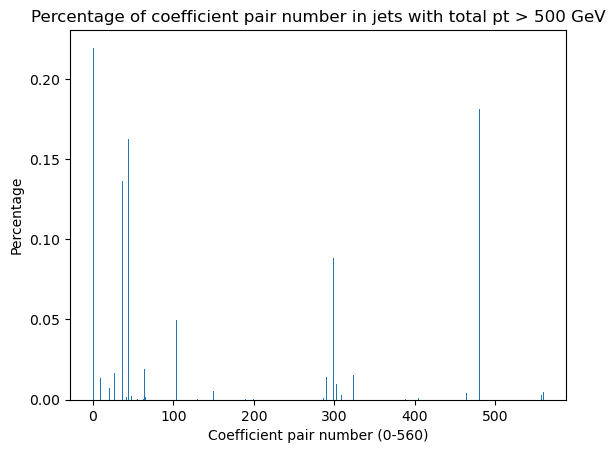

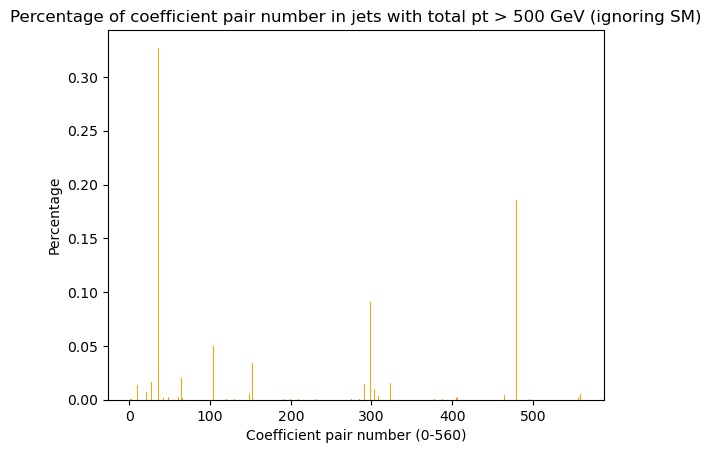

In [226]:
fig1 = plt.figure()
plt.hist(eft_coeff_above_500, bins = 500, weights = weights(eft_coeff_above_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with total pt > 500 GeV')

fig2 = plt.figure()
plt.hist(eft_coeff_above_500_filtering_out_SM, bins = 500, weights = weights(eft_coeff_above_500_filtering_out_SM), color = 'orange')
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with total pt > 500 GeV (ignoring SM)')

plt.show()

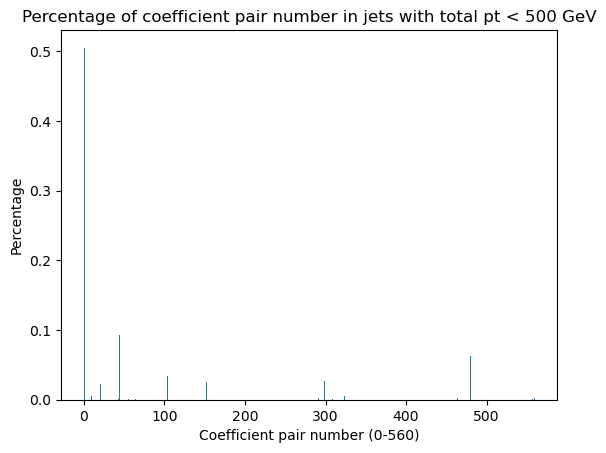

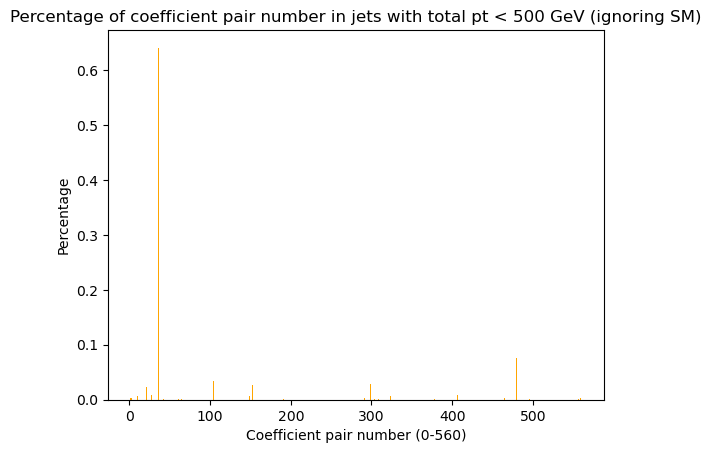

In [234]:
fig3 = plt.figure()
plt.hist(eft_coeff_below_500, bins=520, weights = weights(eft_coeff_below_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with total pt < 500 GeV')

fig4 = plt.figure()
plt.hist(eft_coeff_below_500_filtering_out_SM, bins = 500, weights = weights(eft_coeff_below_500_filtering_out_SM), color='orange')
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with total pt < 500 GeV (ignoring SM)')

plt.show()

In [71]:
def interesting_coeff(data):
    percent_and_index = []
    for i in range(561):
        coeff_percentage = data.count(i) / len(data)
        if coeff_percentage >= 0.01:
            percent_and_index.append([round(coeff_percentage*100), i])
    
           
    percent_and_index = np.array(percent_and_index)
    indices = np.argsort(percent_and_index[:,0])                # This tells me the order of the rows
    percent_and_index_ordered = percent_and_index[indices][::-1] # This sorts the rows based on the indices and [::-1] makes it go in descending order
    
    for i in range(len(percent_and_index_ordered)):
        a = print(f'The pair {name_combinations[percent_and_index_ordered[i,1]]} with index {percent_and_index_ordered[i,1]} has {percent_and_index_ordered[i,0]}%')

    return a

In [136]:
interesting_coeff(eft_coeff_above_500)

The pair ['SM', 'SM'] with index 0 has 22%
The pair ['cQq11', 'cQq13'] with index 480 has 18%
The pair ['ctG', 'ctG'] with index 44 has 16%
The pair ['ctG', 'SM'] with index 36 has 14%
The pair ['ctq1', 'ctq1'] with index 299 has 9%
The pair ['cbW', 'cbW'] with index 104 has 5%
The pair ['cptb', 'cptb'] with index 152 has 3%
The pair ['ctu1', 'ctu1'] with index 324 has 2%
The pair ['cpQ3', 'cpQ3'] with index 27 has 2%
The pair ['ctW', 'ctZ'] with index 64 has 2%
The pair ['ctq1', 'cQq13'] with index 291 has 1%
The pair ['cQu1', 'cQu1'] with index 9 has 1%


In [29]:
# High pt, including SM
interesting_coeff(eft_coeff_above_500,'high')

["The pair ['SM', 'SM'] has index 0 and has a percentage 22% in high pt",
 "The pair ['cQu1', 'cQu1'] has index 9 and has a percentage 1% in high pt",
 "The pair ['cpQ3', 'cpQ3'] has index 27 and has a percentage 2% in high pt",
 "The pair ['ctG', 'SM'] has index 36 and has a percentage 14% in high pt",
 "The pair ['ctG', 'ctG'] has index 44 and has a percentage 16% in high pt",
 "The pair ['ctW', 'ctZ'] has index 64 and has a percentage 2% in high pt",
 "The pair ['cbW', 'cbW'] has index 104 and has a percentage 5% in high pt",
 "The pair ['cptb', 'cptb'] has index 152 and has a percentage 3% in high pt",
 "The pair ['ctq1', 'cQq13'] has index 291 and has a percentage 1% in high pt",
 "The pair ['ctq1', 'ctq1'] has index 299 and has a percentage 9% in high pt",
 "The pair ['ctu1', 'ctu1'] has index 324 and has a percentage 2% in high pt",
 "The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 18% in high pt"]

In [245]:
# High pt, ignoring SM
interesting_coeff(eft_coeff_above_500_filtering_out_SM,'high')

The pair ['ctG', 'SM'] has index 36 and has a percentage 33% in high pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 17% in high pt
The pair ['ctq1', 'ctq1'] has index 299 and has a percentage 9% in high pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 19% in high pt


In [246]:
# Low pt, including SM
interesting_coeff(eft_coeff_below_500,'low')

The pair ['SM', 'SM'] has index 0 and has a percentage 50% in low pt
The pair ['ctG', 'SM'] has index 36 and has a percentage 19% in low pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 9% in low pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 6% in low pt


In [247]:
# Low pt, ignoring SM
interesting_coeff(eft_coeff_below_500_filtering_out_SM,'low')

The pair ['ctG', 'SM'] has index 36 and has a percentage 64% in low pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 11% in low pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 8% in low pt


In [261]:
pair_number = 299
number_of_coefficient = 0
list_to_look_into = eft_coeff_below_500_filtering_out_SM
name_of_list = 'Jets below total 500 GeV'

for i in list_to_look_into:
    if i == pair_number:
       number_of_coefficient += 1 
print(f'The pair #{pair_number} appears {number_of_coefficient} times in EFT {name_of_list}' )

The pair #299 appears 662 times in EFT Jets below total 500 GeV


In [262]:
number_of_coefficient / len(eft_coeff_below_500_filtering_out_SM)

0.0293569844789357

In [ ]:
# ------------------------------------------------- Two leading leptons pt ----------------------------------------------------------- #

In [7]:
%%time
# Sneha's Script:
# leptons can be either electron muon or tau. 
# pick two leading leptons and then sum their pt.
# TODO : output an array with the two leading leptons for each event. 

elec_pt = events_tree['Electron_pt'].array()
mu_pt = events_tree['Muon_pt'].array()
tau_pt = events_tree['Tau_pt'].array()

elec_eta = events_tree['Electron_eta'].array()
mu_eta = events_tree['Muon_eta'].array()
tau_eta = events_tree['Tau_eta'].array()

two_leading_leptons = [[]]
for i in range(len(elec_pt)):
    leading_pts, ptlist = [],[]
    ptlist.extend(elec_pt[i])
    ptlist.extend(mu_pt[i]) 
    ptlist.extend(tau_pt[i])
    leading_pts.append(max(ptlist))
    ptlist.remove(max(ptlist))
    leading_pts.append(max(ptlist))
    two_leading_leptons.append(leading_pts)

two_leading_leptons = np.array(two_leading_leptons[1:])

CPU times: user 12 s, sys: 36.4 ms, total: 12 s
Wall time: 12.1 s


In [360]:
# Separating first and second lepton
first_lepton = two_leading_leptons[:,0]
second_lepton = two_leading_leptons[:,1]

In [92]:
# Making function to get the index (0-560) of the largest coefficient in events with GeV > cutoff 
def eft_coeff_leptons(data, cutoff):
    cut_list = data > cutoff
    eft_coeff_lepton = []
    
    for i,n in enumerate(cut_list):                                       
        if n == True:
            eft_coeff_lepton.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)
            # +1 since the new list gets shifted by ignoring the first coefficient, but np.argmax doesn't know this...
            
    return(eft_coeff_lepton)

In [99]:
# Running function for first lepton with cutoff at 50 GeV and second lepton with cutoff at 30 GeV
eft_coeff_first_lepton = eft_coeff_leptons(first_lepton, 50)
eft_coeff_second_lepton = eft_coeff_leptons(second_lepton, 30)

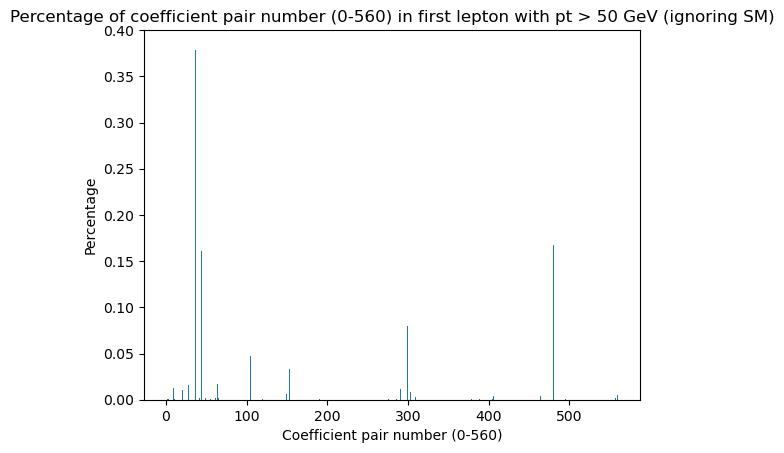

The pair ['ctG', 'SM'] with index 36 has 38%
The pair ['cQq11', 'cQq13'] with index 480 has 17%
The pair ['ctG', 'ctG'] with index 44 has 16%
The pair ['ctq1', 'ctq1'] with index 299 has 8%
The pair ['cbW', 'cbW'] with index 104 has 5%
The pair ['cptb', 'cptb'] with index 152 has 3%
The pair ['ctW', 'ctZ'] with index 64 has 2%
The pair ['cpQ3', 'cpQ3'] with index 27 has 2%
The pair ['ctq1', 'cQq13'] with index 291 has 1%
The pair ['ctu1', 'ctu1'] with index 324 has 1%
The pair ['cpQ3', 'SM'] with index 21 has 1%
The pair ['cQu1', 'cQu1'] with index 9 has 1%


In [144]:
# Plotting histogram for first lepton and also printing the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_first_lepton, bins = 500, weights = weights(eft_coeff_first_lepton))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number (0-560) in first lepton with pt > 50 GeV (ignoring SM)')
plt.ylim(0,0.4)
plt.show()

interesting_coeff(eft_coeff_first_lepton)

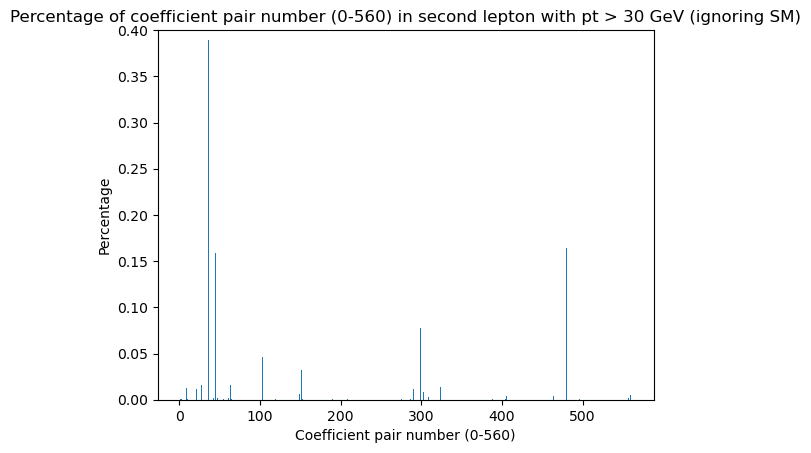

The pair ['ctG', 'SM'] with index 36 has 39%
The pair ['cQq11', 'cQq13'] with index 480 has 16%
The pair ['ctG', 'ctG'] with index 44 has 16%
The pair ['ctq1', 'ctq1'] with index 299 has 8%
The pair ['cbW', 'cbW'] with index 104 has 5%
The pair ['cptb', 'cptb'] with index 152 has 3%
The pair ['ctW', 'ctZ'] with index 64 has 2%
The pair ['cpQ3', 'cpQ3'] with index 27 has 2%
The pair ['ctq1', 'cQq13'] with index 291 has 1%
The pair ['ctu1', 'ctu1'] with index 324 has 1%
The pair ['cpQ3', 'SM'] with index 21 has 1%
The pair ['cQu1', 'cQu1'] with index 9 has 1%


In [134]:
# Plotting histogram for second lepton and also the interesting coefficients (higher than 5%)
plt.hist(eft_coeff_second_lepton, bins = 520, weights = weights(eft_coeff_second_lepton))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number (0-560) in second lepton with pt > 30 GeV (ignoring SM)')
plt.ylim(0,0.4)
plt.show()

interesting_coeff(eft_coeff_second_lepton)

In [8]:
%%time
# My method for the lepton pt and lepton eta!

leading_leptons_pt = []
leading_leptons_eta = []

for i in range(len(elec_pt)):
    lepton_pt = np.concatenate((elec_pt[i],mu_pt[i],tau_pt[i]), axis = 0)         # concatenating all lepton pt and lepton eta
    lepton_eta = np.concatenate((elec_eta[i],mu_eta[i],tau_eta[i]), axis = 0)      
    order = np.argsort(lepton_pt)                                                 # order for values in ascending order
    lepton_pt_sorted = lepton_pt[order]                                           # sorting the lepton pt and lepton eta using the order given above
    lepton_eta_sorted = lepton_eta[order]                                          
    leading_leptons_pt.append([lepton_pt_sorted[-1],lepton_pt_sorted[-2]])        # appending largest values for lepton pt and lepton eta
    leading_leptons_eta.append([lepton_eta_sorted[-1],lepton_eta_sorted[-2]])

leading_leptons_pt = np.array(leading_leptons_pt)
leading_leptons_eta = np.array(leading_leptons_eta)

CPU times: user 1min 16s, sys: 283 ms, total: 1min 16s
Wall time: 1min 17s


In [11]:
print(leading_leptons_eta[10023])
print(f'\n {np.concatenate((elec_pt[10023],mu_pt[10023],tau_pt[10023]), axis = 0)}')
print(f'\n {np.concatenate((elec_eta[10023],mu_eta[10023],tau_eta[10023]), axis = 0)}')

[1.1479492 1.137207 ]

 [68.9, 57.7, 55.6, 24.9, 11.9, 11.6, 4.67, 94, 58.6]

 [1.14, -0.356, 1.31, 0.518, 1.18, 0.474, 0.522, 1.15, -0.355]


In [379]:
# Making sure that both methods give the same results
checking_first_lepton = leading_leptons_pt[:,0] == first_lepton # I defined first_lepton and second_lepton below Sneha's code
checking_second_lepton = leading_leptons_pt[:,1] == second_lepton

print(False in checking_first_lepton)
print(False in checking_second_lepton)

False
False


In [382]:
leading_leptons_eta

array([[ 1.126709  ,  1.126709  ],
       [-0.1265564 , -1.2883301 ],
       [-0.9366455 , -0.95214844],
       ...,
       [-1.0209961 , -1.0556641 ],
       [ 1.4943848 ,  1.9116211 ],
       [-0.0027647 , -0.33422852]], shape=(78146, 2), dtype=float32)

In [131]:
# Getting the mean and median of the coefficient values
mean = []
median = []

for i in range(561):
    mean.append(np.mean(eft_coeff[:,i]))
    median.append(np.median(eft_coeff[:,i]))

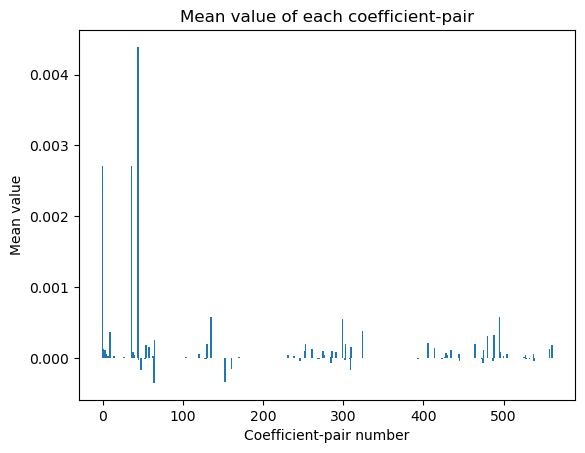

The following indices have a value higher than 0.001

 Index: 0 has mean 0.002709

 Index: 36 has mean 0.00271

 Index: 44 has mean 0.00439


In [132]:
# Plotting the mean and median of the coefficient values
coeffs = np.arange(0,561)

plt.bar(coeffs,mean, width = 2)
plt.xlabel('Coefficient-pair number')
plt.ylabel('Mean value')
plt.title('Mean value of each coefficient-pair')
#plt.yscale('log')
plt.show()
print('The following indices have a value higher than 0.001')
for i,n in enumerate(mean):
    if abs(n) > 0.001:
        print(f'\n Index: {i} has mean {np.round(n,decimals = 6)}')

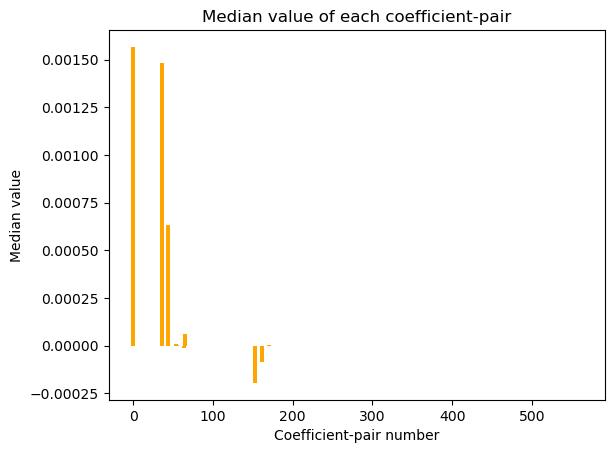

The following indices have a value higher than 0.00025

 Index: 0 has median 0.0015670000575482845

 Index: 36 has median 0.0014850000152364373

 Index: 44 has median 0.0006350000039674342


In [133]:
plt.bar(coeffs,median, color='orange',width = 5)
plt.xlabel('Coefficient-pair number')
plt.ylabel('Median value')
plt.title('Median value of each coefficient-pair')
#plt.yscale('log')
plt.show()

print('The following indices have a value higher than 0.00025')
for i,n in enumerate(median):
    if abs(n) > 0.00025:
        print(f'\n Index: {i} has median {np.round(n, decimals = 6)}')

In [163]:
# IMPORTANT NOTE FOR THE MEAN: The highest mean corresponds to coefficient #44. If you take a look at the values in each event for
# this pair, you will see it has pretty big numbers compared to other lists! For example, the largest value is 18.9, where coefficient #0
# has a max of 0.1. Compare the lists with the code right below.

eft_coeff_44_sorted = np.sort(eft_coeff[:,44])[::-1] # Sorted from max to min
eft_coeff_44_sorted[0] # Printing the first_value

np.float32(18.86914)

In [164]:
# Pick whatever coeff index you want to sort from max to min:
coeff_of_interest = 0
eft_coeff_of_interest_sorted = np.sort(eft_coeff[:,coeff_of_interest])[::-1] # Sorted from max to min
eft_coeff_of_interest_sorted[0] # Printing the first value (max value)

np.float32(0.1004982)